# Name
Please write your name down here:

Peter Brederlow

**Today's topics**
We will try to find out which phenotypic traits are associated with genetic markers in the BXD mouse population. This will allow us to make statements about the level of heritability of several traits and help us identify candidate genes responsible for specific traits.

There are several types of studies relevant in this context:

* Single gene association studies
* Genome wide association studies
* Phenome wide association studies

Today we'll perform a genome-wide association study. In particular, we will investigate which SNPs are associated with the coat color of mice.

In [241]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.sandbox.stats.multicomp import multipletests
import scipy.stats

pd.set_option('future.no_silent_downcasting', True)

/var/folders/vm/8qbbn1f91lb9f4yl4gd82lch0000gn/T/ipykernel_23357/459652307.py:8: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


# Load genotype data
To ensure that we all use the same input data, we provide the code you should load the genotype information with.

We split the table into metadata (`geno_meta`) and genotype data (`geno_bdh`) parts and index them with the `Locus` identifier.

In [242]:
genotype = pd.read_csv(
    "https://github.com/Practical-Integrative-Bioinformatics/00_Introduction/blob/main/data/genotype.txt?raw=True", 
    sep="\t", 
    comment="@"
)
genotype.set_index("Locus", inplace=True)
geno_meta = genotype.iloc[:, :3]  # 3 because we had just moved the "Locus" column into the index
geno_bdh = genotype.iloc[:, 3:]

geno_bdh.head()

,BXD1,BXD2,BXD5,BXD6,BXD8,BXD9,BXD11,BXD12,BXD13,BXD14,...,BXD90,BXD91,BXD93,BXD94,BXD95,BXD98,BXD99,BXD100,BXD101,BXD102
Locus,,,,,,,,,,,,,,,,,,,,,
rs6269442,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,B
rs6365999,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs6376963,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs3677817,B,B,D,D,D,B,B,D,B,B,...,B,D,B,D,D,B,B,B,B,U
rs8236463,B,B,D,D,D,B,D,D,B,B,...,B,D,B,D,D,B,B,B,B,U


## Remove strains with a lot of missing genotype values
Before you convert the B/D/H/U labels to numeric, find the main culprits for the U (unknown) labels.
Only keep strains with less than 10 unknown loci and put them in `geno_bdh2`. Which strains did you have to remove?

In [243]:
# YOUR CODE HERE
u_counts = geno_bdh.apply(lambda col: (col == 'U').sum())
excluded_genotypes = u_counts[u_counts >= 10]
print(excluded_genotypes)
geno_bdh2 = geno_bdh.loc[:, u_counts < 10]

BXD73b    487
BXD101    521
BXD102    657
dtype: int64


In [244]:
assert 'geno_bdh2' in locals()

## Replace categorical genotype labels with numerical encoding

Unlike yesterday, we will use `{B: 0, H: 1, D: 2, U: 1}` encoding for the genotypes. Due to the previous step where we discarded strains with a lot of missing data, we have very few unknowns left, so it's acceptable to treat them as the intermediate heterozygous genotype instead of missing values. Call the numerical genotype dataframe `geno`.

In [245]:
# YOUR CODE HERE
geno_bdh2 = geno_bdh2.replace({'B': 0.0, 'H': 1.0, 'D': 2.0, 'U': 1.0})
geno = geno_bdh2.astype(float)

In [246]:
assert 'geno' in locals()

## Load coat color data as `colors_df`

For your convencience (and ours, because the data might still change or not be accessible), we have already prepared the coat color data:

`https://github.com/Practical-Integrative-Bioinformatics/00_Introduction/blob/main/data/BXD_11280.csv?raw=True`

The colors are already numerically encoded, so you don't have to convert it yourself. But keep an eye out for missing values and remove them if they exist. For future reference, the color encoding is:

|color  | value  |
|-------|--------|
| black |  4     |
| grey  |  3     |
| brown |  2     |
| dilute|  1     |

The final DataFrame should only have two columns: `strain` and `color`. Finally, set `strain` as index.

In [247]:
# YOUR CODE HERE
url = 'https://github.com/Practical-Integrative-Bioinformatics/00_Introduction/blob/main/data/BXD_11280.csv?raw=True'
colors_df = pd.read_csv(url, skiprows=9, header = 1, index_col='Name')
colors_df = colors_df[['Value']]
colors_df

,Value
Name,
C57BL/6J,4.0
DBA/2J,1.0
B6D2F1,4.0
D2B6F1,4.0
BXD1,1.0
...,...
BXD216,1.0
BXD217,4.0
BXD218,4.0


In [248]:
assert 'colors_df' in locals()

# Association tests between variants and categorical phenotype
We will first start testing SNPs for their association with a *categorical* phenotype, coat color. It is known to be heritable, and therefore genetically determined to a large extent, so we'll try to find candidate genes that could be involved. The fist step is finding the right SNPs.

## Perfom association test for a single SNP using $\chi^2$ test

The chi2 test is a suitable test to detect association between two categorical random variables. It compares their observed combination counts with the combination counts that would be expected if there was no association between the two variables. The p-value calculated by the chi2 test is a measure of how likely it is for the expected and actual combination counts to differ as much as they do by mere chance.

### Line up `geno` and `colors`

We have genotype information for a set of mouse strains, and color information for a largely overlapping, but different set. We can only use those strains in the analysis that are present in both datasets. So we should first find their intersection, and slice both datasets accordingly.

Before you do that though, notice that the strains C57BL/6J and DBA/2J (only present in the color dataset) are the original founders of the entire BXD strain family: C57BL/6J is B, and DBA/2J is D. Therefore you know their genotypes by definition: all B and all D on every locus. Insert them into `geno` accordingly.

Furthermore, since the coat color DataFrame has just one column, it really should be a Series instead, as storing 1-dimensional data in a 2-dimensional data structure for no good reason is potential source of bugs. It's only a DataFrame in the first place is because `pd.read_csv` produces DataFrames regardless of the input file's shape. Slice the color DataFrame's only column and store it in the `colors` Series.

In [249]:
# YOUR CODE HERE
#add founder genotypes and change colors
geno['C57BL/6J'] = 0.0
geno['DBA/2J'] = 2.0
colors = pd.Series(colors_df['Value'])

#onyl retain agreeing rows
common_indices = geno.columns.intersection(colors.index)
colors = colors.loc[common_indices]
geno = geno[common_indices] 

In [250]:
assert 'geno' in locals()
assert 'colors' in locals()

### Extract the genotype information for a single SNP
Store it in the variable `one_geno`.

In [251]:
# YOUR CODE HERE
one_geno = geno.iloc[69] 
one_geno

BXD1        2.0
BXD2        0.0
BXD5        0.0
BXD6        2.0
BXD8        2.0
           ... 
BXD98       2.0
BXD99       0.0
BXD100      0.0
C57BL/6J    0.0
DBA/2J      2.0
Name: rs13475827, Length: 89, dtype: float64

### Plot relationship between genotye and phenotype
You can use a scatter plot, but equal values will occlude each other, so you should add some jitter (small random noise). You can achieve this by generating random values in the same shape as your DataFrame, and adding it.

You can also try a heatmap, but make sure your color range starts from zero.

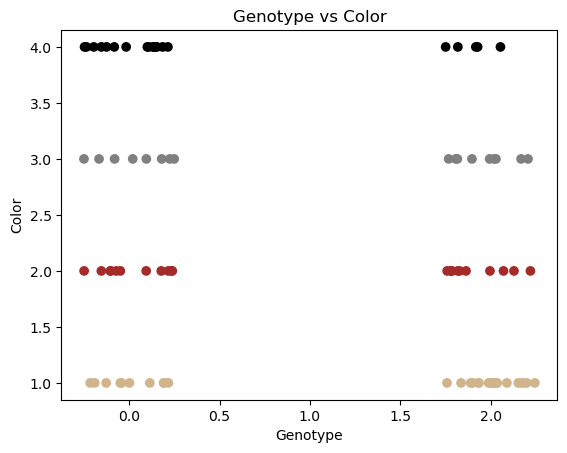

In [252]:
# YOUR CODE HERE
#add jitter around the points
jitter = np.random.uniform(-0.25, 0.25, size=len(one_geno))
value_to_color = {
    4: 'black',
    3: 'grey',
    2: 'brown',
    1: 'tan',
}
mapped_colors = [value_to_color[val] for val in colors]
plt.scatter(one_geno + jitter, colors, color=mapped_colors)
plt.xlabel('Genotype')
plt.ylabel('Color')
plt.title('Genotype vs Color')
plt.show()

### Create a contingency table for a D-dominant inheritance model of black coat color for your SNP

**What does D-dominant mean here, how should you treat the heterozygous genotype?** Think about the individual cells of the contingency matrix: it has a 2x2 shape, but you have 3 kinds of genotypes and 4 kinds of colors. How should you collapse your data to binary labels?

<div class="alert alert-block alert-info"><b>Tip: </b> Pandas' <code>crosstab</code> functionality may be helpful for you.</div>

In [253]:
# YOUR CODE HERE
geno_binary = ['D-dominant' if g == 2 or g == 1 else 'Recessive' for g in one_geno]
color_binary = ['Black' if c == 4 else 'Non-black' for c in colors]
contingency_table = pd.crosstab(pd.Series(geno_binary, name='Genotype'), 
                                pd.Series(color_binary, name='Coat Color'))

print(contingency_table)

Coat Color  Black  Non-black
Genotype                    
D-dominant      5         40
Recessive      15         29


One tests black against other colors, so differentiates between those two, and one differentiates between genes being heterozygous or homozygous for D as being of Genotype D and else not.

### Perform a $\chi^2$ square test for independence on the contingency table

Find a suitable method in `scipy.stats` and read its documentation to understand what the returned values are. How can you access the test's p-value?

In [254]:
# YOUR CODE HERE
chi2, p, dof, expected = scipy.stats.chi2_contingency(contingency_table)
print(f"Chi-squared: {chi2}, p-value: {p}")

Chi-squared: 5.488732341531256, p-value: 0.019139415404123103


### Sidenote: penetrance models instead of dominance models

We have just used a D-dominant model with a 2x2 contingency table and performed a $\chi^2$ test with the smallest possible degrees of freedom (1). We assumed that a heterozygous genotype behaves the same way as a homozygous D genotype does.

It is sometimes useful to consider the full complexity of a genotype considering all three possible genotypes instead of just two. We could have used a $\chi^2$ test  with a 3x2 contingency table, and thus 2 degrees of freedom, but a more popular choice for such models is the Cochran–Armitage trend test, which usually has larger statistical power. In this case, the "penetrance" of the D allele is assumed to be additive: two alleles makes it twice as likely to exhibit the trait than one.

You can read more about basic statistical approaches in genetic association tests in the following paper:

__G. Clarke et al.       
[Basic statistical analysis in genetic case-control studies](http://www.nature.com/nprot/journal/v6/n2/full/nprot.2010.182.html)__,      
Nat. Protocols, 2011/02,     
http://dx.doi.org/10.1038/nprot.2010.182
<br>
<br>

For this task, you don't have to write code, just answer this one question: **Would it make practical sense to use such a model with our data? Why?**

The Cochran-Armitage Trend Test assumes either a numerical variable or an ordinally scaled variable to predict the binary variable (in this case it would be color). This assumed ordering is present, since heterozygous are intermediate between the homzygous genotypes (1, homozygous being 0 and 2), and the direction of the ordinal scale is not relevant for the significance of the test.  
However, we did not consider heterozygous anyways

Clarke, G. M., Anderson, C. A., Pettersson, F. H., Cardon, L. R., Morris, A. P., & Zondervan, K. T. (2011). Basic statistical analysis in genetic case-control studies. Nature Protocols 2011 6:2, 6(2), 121–133. https://doi.org/10.1038/nprot.2010.182

## Refactor the previous analysis steps into a function `chi2_geno_coat` and apply to all SNPs

Try to do it without writing any `for` loops. Use the built-in iterating functionality that pandas provides with the `apply` method.
Store your resulting p-values in `p_values`.

If you are ahead of schedule, you could try to come up with a faster approach. Doing 3811 cross-tabulations from scratch might be a bit wasteful, since the coat color labels are constant in every iteration. It is possible to calculate all 3811 contingency table values with a few simple operations, and therefore run all chi2 tests in a matter of seconds instead of a minute.

But speed doesn't really matter for us now. Whichever way you do it, answer the following question:

**How many SNPs are associated with coat color at a p<0.05 significance threshold?**

In [255]:
# YOUR CODE HERE
def calculate_chi2(geno_column, color):
        geno_binary = geno_column.apply(lambda g: 'D-dominant' if g == 2 or g == 1 else 'Recessive')
        color_binary = color.apply(lambda c: 'Black' if c == 4 else 'Non-black')
        contingency_table = pd.crosstab(
            pd.Series(geno_binary, name='Genotype'),
            pd.Series(color_binary, name='Coat Color')
        )
        chi2, p, dof, expected = scipy.stats.chi2_contingency(contingency_table)
        return p 
def chi2_geno_coat(geno, color):
    p_values = pd.Series(index=geno.index)
    p_values = (geno.apply(lambda row: calculate_chi2(row, color), axis=1))
    return p_values
p_values = chi2_geno_coat(geno, colors)

    

In [256]:
assert 'chi2_geno_coat' in locals()
assert 'p_values' in locals()

### Add the p-values to the SNP metadata (`geno_meta`) DataFrame

Insert them as a new column called `p_raw`.

In [257]:
# YOUR CODE HERE
p_values = p_values.astype(float)
geno_meta = geno_meta.merge(p_values.rename('p_raw'), left_index=True, right_index=True)
significant_values = geno_meta[geno_meta['p_raw'] < 0.05]
print(len(significant_values))

253


In [258]:
assert 'p_raw' in geno_meta.columns

### Create a Manhattan Plot of  $-\log_{10}(\text{P-value})$ vs chromosome position 
A Manhattan plot, named after its resemblance to the skyline of Manhattan, is commonly used to plot the p-values of SNP association tests against their genomic position.

Technically, it's a scatter plot of genome position vs the negative base-10 logarithm of the p-value (~how many zeroes does the p-value begin with). Try to recreate something like the plot below. It doesn't have to be an exact match, but at least the chromosomes should be distinguishable.

Think about how to convert chromosome number + Mb position within the chromosome into a single absolute position on the x-axis.

Hints: you can iterate over a pandas `groupby` object, so you can plot p-values chromosome-by-chromosome. This would mean 20 successive plotting calls in a `for` loop, which is perfectly fine.

Watch out: the `Chr` column may look numeric, but it is in fact a string column due to the `X` chromosome. If you don't want them to be sorted as strings (1, 10, 11, ..., 19, 2, 3, 4) you can prevent it by passing `sort=False` to the `geno_meta.groupby(...)` method as a keyword argument.

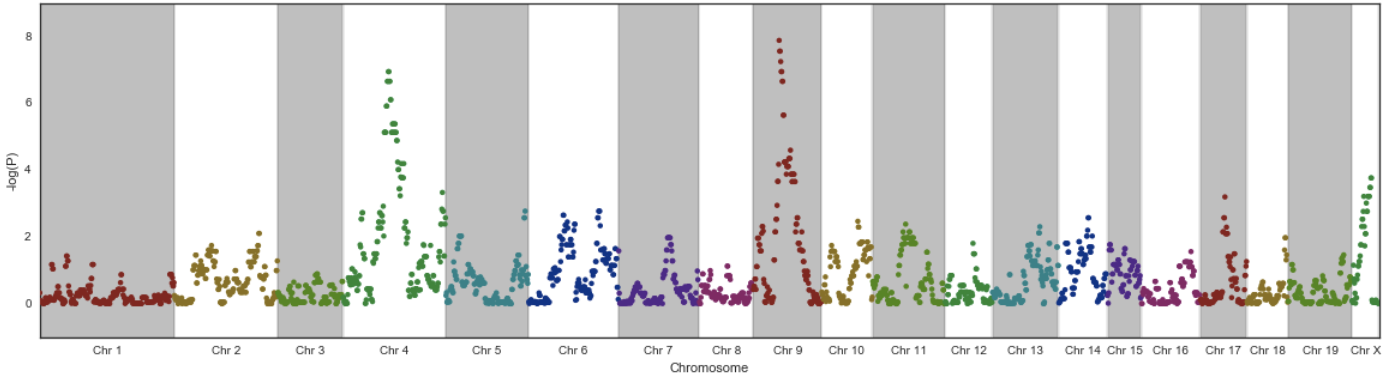

In [259]:
# YOUR CODE HERE
geno_meta['log_p'] = -np.log10(geno_meta['p_raw'])
geno_meta['Chr'] = geno_meta['Chr'].astype(str)
chromosome_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
geno_meta['Chr'] = pd.Categorical(geno_meta['Chr'], categories=chromosome_order, ordered=True)
geno_meta



,Chr,cM,Mb,p_raw,log_p
Locus,,,,,
rs6269442,1,0.000,3.482275,0.012001,1.920792
rs6365999,1,0.000,4.811062,0.012001,1.920792
rs6376963,1,0.895,5.008089,0.058495,1.232882
rs3677817,1,1.185,5.176058,0.074896,1.125544
rs8236463,1,2.081,5.579193,0.246533,0.608126
...,...,...,...,...,...
CEL-X_154259201,X,71.490,160.727278,0.180213,0.744214
rs3657281,X,71.776,160.951099,0.349773,0.456214
rs13484106,X,71.776,162.637897,0.349773,0.456214


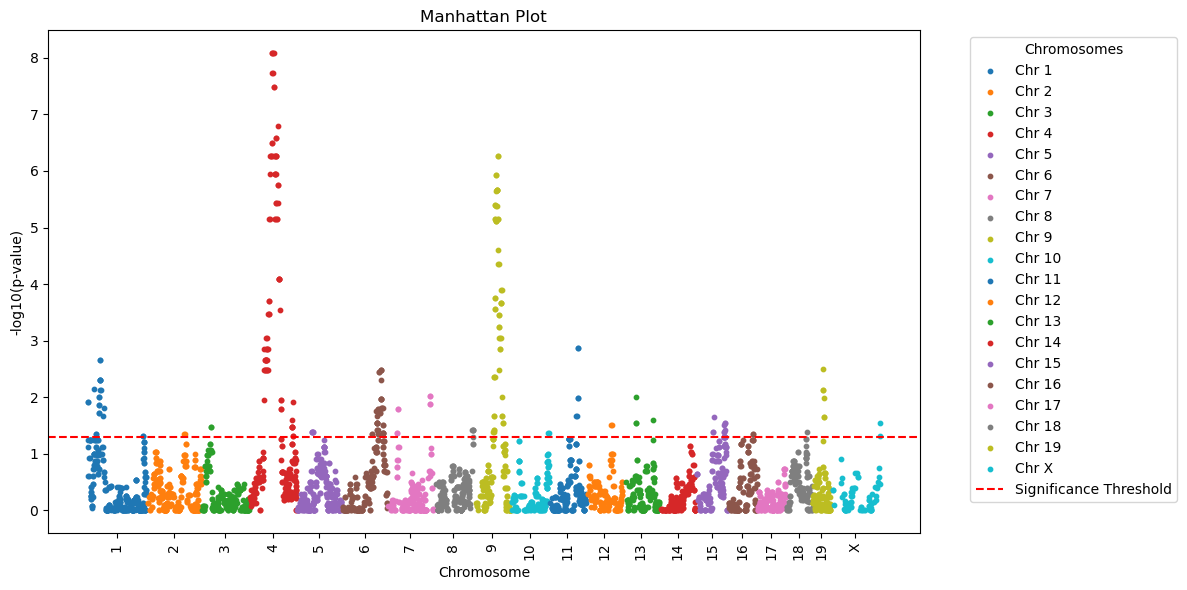

In [260]:
chromosome_offsets = geno_meta.groupby('Chr')['Mb'].max().cumsum().shift(fill_value=0)
chromosome_midpoints = chromosome_offsets + geno_meta.groupby('Chr')['Mb'].max() / 2
geno_meta['cumulative_mb'] = geno_meta['Mb'] + geno_meta['Chr'].map(chromosome_offsets)

plt.figure(figsize=(12, 6))
for chrom, group in geno_meta.groupby('Chr'):
    plt.scatter(group['cumulative_mb'], group['log_p'], s=10, label=f'Chr {chrom}')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold')
plt.xlabel('Chromosome')
plt.xticks(chromosome_midpoints, chromosome_midpoints.index, rotation=90)
plt.ylabel('-log10(p-value)')
plt.title('Manhattan Plot')
plt.legend(title='Chromosomes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Correction for Multiple Hypothesis Testing

### Preliminary task: p-value histograms

Plot a histogram of all the p-values that you got from the $\chi^2$ tests. Generate the same amount of random uniformly distributed values between [0,1], and put them on the same histogram for a baseline comparison. (Remember, a chi2 test, or any well-calibrated statistical test would always produce a uniform distribution if there was no association between two random variables.)

**Will any of our p-values survive multiple testing correction in your opinion?** If so, guess how many! If necessary, increase the number of bins to capture the differences between the two histograms near p=0.

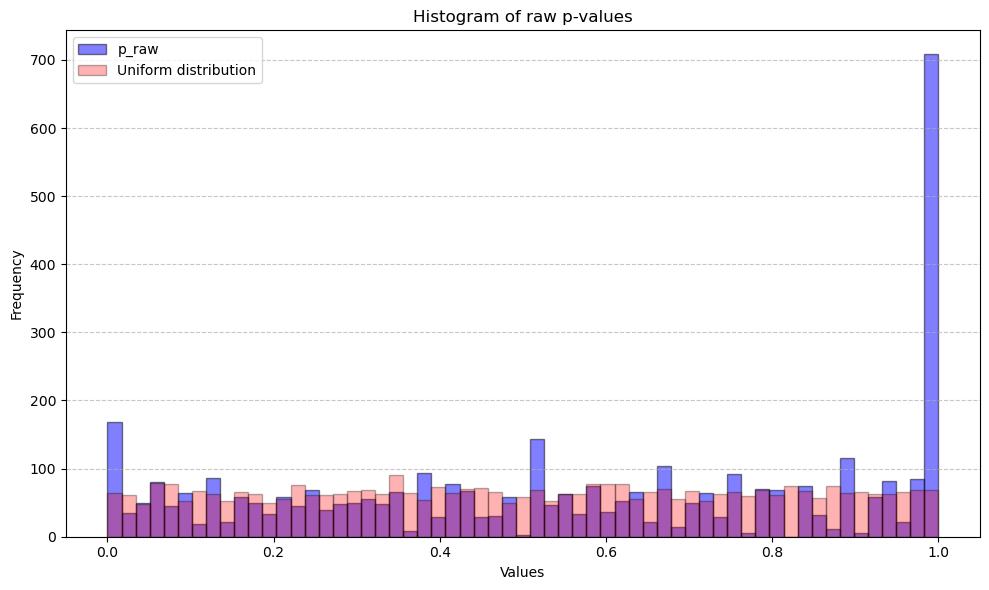

In [261]:
# YOUR CODE HERE
min_value = geno_meta['p_raw'].min()  
max_value = geno_meta['p_raw'].max() 
uniform_p_values = np.random.uniform(low=min_value, high=max_value, size=len(geno_meta['p_raw']))
bins = np.linspace(min_value, max_value, 60)  
plt.figure(figsize=(10, 6))
plt.hist(geno_meta['p_raw'], bins=bins, color='blue', alpha=0.5, edgecolor='black', label='p_raw')
plt.hist(uniform_p_values, bins=bins, color='red', alpha=0.3, edgecolor='black', label='Uniform distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of raw p-values')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Generally, there already is a high amount of 1 p-values already, the rest fluctuates as well, but is fairly uniformly distributed. Because of that, I assume that the vast majority of p-values will be shrunken to 1, but a few will probably survive the multiple testing correction.

### Use the Benjamini-Hochberg correction method to take care of the multiple hypothesis testing problem

Insert the B-H corrected p-values into the locus information DataFrame `geno_meta` as a new column named `p_bh`.

**After the Benjamini-Hochberg correction, how many SNPs stayed significantly associated with coat color at the p<0.05 level? Compare this number with your earlier guess based on the raw p-value histogram. (And perhaps ponder: have we *really* tested 3811 different association hypotheses?)**

In [262]:
# YOUR CODE HERE
geno_meta['p_bh'] = multipletests(geno_meta['p_raw'], method='fdr_bh')[1]
sig = geno_meta[geno_meta['p_bh'] < 0.05]
print(len(sig))


89


In [263]:
assert 'p_bh' in geno_meta.columns

There are 89 significant genes, furthermore we did not really test perfectly independent hypotheses because of the Linakge Disqeuilibrium. This essentially means, that SNPs that are close in chromosomal distance will get inherited toether more often, violating the independence assumptions.

### Plot a histogram of the corrected p-values

Compare it with the original histogram of raw p-values. Does it match your expectations?

If you want, you can also try to recreate the Manhattan plot with the corrected p-values this time.

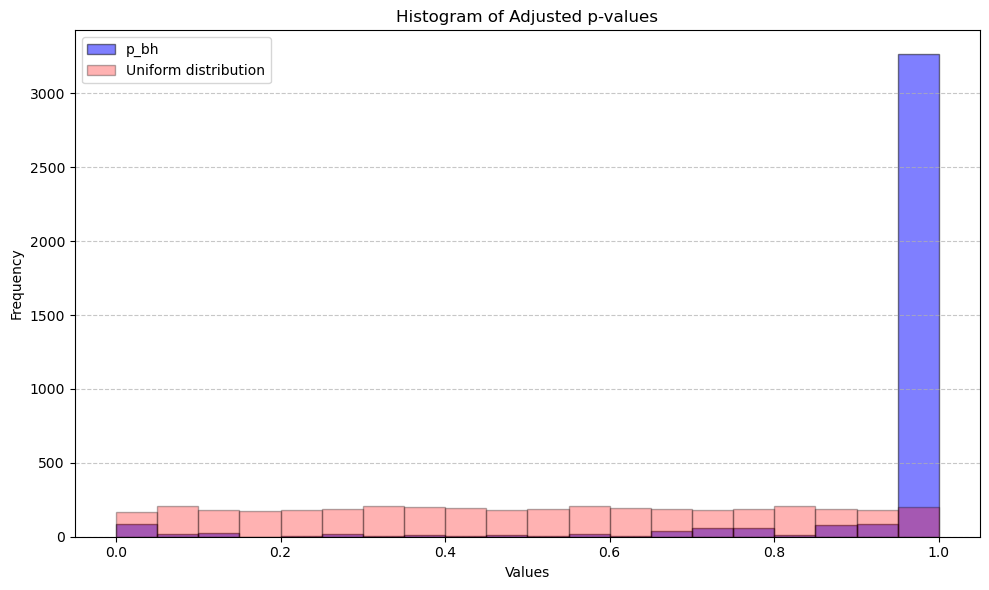

In [264]:
# YOUR CODE HERE
min_value = geno_meta['p_bh'].min()  
max_value = geno_meta['p_bh'].max() 
bins = np.linspace(min_value, max_value, 21)  
plt.figure(figsize=(10, 6))
plt.hist(geno_meta['p_bh'], bins=bins, color='blue', alpha=0.5, edgecolor='black', label='p_bh')
plt.hist(uniform_p_values, bins=bins, color='red', alpha=0.3, edgecolor='black', label='Uniform distribution')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram of Adjusted p-values')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

It is clearly visible, that most p-values were shrunken to 0, and only a few sinificant genes remain.

## Identify candidate genes from the significantly associated loci

What we identified so far are trait associated SNPs. This doesn't mean there is directly a causal relationship between the markers identified in the association study and the phenotype. It is, however, a pointer towards the region of the genome that may be relevant for the variability in the measured trait. The genes encompassed in this region then need to be analysed further to identify viable mechanistic candidates.

A good starting point for this fine grained analysis would be to look up the genes directly linked to the interesting SNPs in a mouse genome database (e.g, http://www.informatics.jax.org/snp/ ).

Most likely the high ranking SNPs will not map directly to the causal gene, but will rather be markers for another variant in a gene in strong __linkage disequilibrium__ with these SNPs. We thus need to extend the search and look at other genes in the vicinity of the high ranking SNPs (i.e. the entire region where the best SNPs are found). Since they are typically inherited together, it's hard to say which  of them are the truly causal variants.

Your task is to find candidate *genes* (instead of SNPs) using the website above. Reminder: the original BXD parent strains were called C57BL/6J and DBA/2J. Note that you can query entire regions, and in the query results page you can further filter the listed SNPs based on their properties (e.g. coding variant).

Another resource you can use is the [UCSC Genome Browser](http://genome.ucsc.edu/) for visual explorations, or the [UCSC Table Browser](http://genome.ucsc.edu/cgi-bin/hgTables?hgsid=511555905_oFRLEcH1IWO1FdKyzynrsBCRMk7w) to obtain genes in a genomic region. The identifiers of proteins in the [Uniprot](http://www.uniprot.org/) database are listed in the resulting table. Uniprot then can provide useful annotations of the proteins found in the search frame.

For the truly dedicated, or those with extra time on their hands, programmatic access is possible with the following services via a REST interface:

[UCSC](http://genomewiki.ucsc.edu/index.php/Programmatic_access_to_the_Genome_Browser)     
[Biomart](http://www.ensembl.org/info/data/biomart/biomart_restful.html)    
[Uniprot](http://www.uniprot.org/help/programmatic_access)      

**Check if the genes you found match the literature about genetics of mouse coat color.**

Hint / spoiler: ([PMC2736153](http://www.ncbi.nlm.nih.gov/pmc/articles/PMC2736153)).

The genes at chromosome 4 center at 80Mb, which is close to a gene named Tyrp1 (Geisert et. al, 2009). This is in line with the literature, where the gene is described as well. A mutation of these genes is related to brown color, and hence explains one of the color characteristics. Furthermore, another relevant genomic location is at chromosome 9, also between 70 and 90Mb to the reference. This is related to several mutations regarding the gene Rab27a, which is also called the "dilute gene", since it encodes the diluted color phenotype, being associated with ashy colors (Strobal et. al, 1988).


Strobel MC, Seperack PK, Moore KJ, Copeland NG, Jenkins NA. The dilute coat-color locus of mouse chromosome 9. Prog Clin Biol Res. 1988;256:297-305. PMID: 3368491.
Geisert, E. E., Lu, L., Freeman-Anderson, N. E., Templeton, J. P., Nassr, M., Wang, X., Gu, W., Jiao, Y., & Williams, R. W. (2009). Gene expression in the mouse eye: an online resource for genetics using 103 strains of mice. Molecular Vision, 15, 1730. https://pmc.ncbi.nlm.nih.gov/articles/PMC2736153/